In [3]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/yokou/Projects/cifar10-image-classifier
Data directory: /Users/yokou/Projects/cifar10-image-classifier/data
Figure directory: /Users/yokou/Projects/cifar10-image-classifier/outputs/figures


In [5]:
transform = transforms.ToTensor()

train_dataset = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


In [7]:
classes = train_dataset.classes
print("Classes:", classes)
print("Number of classes:", len(classes))
print("Class distribution in training set:", Counter(train_dataset.targets))
print(train_dataset.class_to_idx)
print("Class distribution in test set:", Counter(test_dataset.targets))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Class distribution in training set: Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Class distribution in test set: Counter({3: 1000, 8: 1000, 0: 1000, 6: 1000, 1: 1000, 9: 1000, 5: 1000, 7: 1000, 4: 1000, 2: 1000})


In [8]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

print("Label ID:", label)
print("Class name:", classes[label])

Image shape: torch.Size([3, 32, 32])
Image dtype: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Label ID: 6
Class name: frog


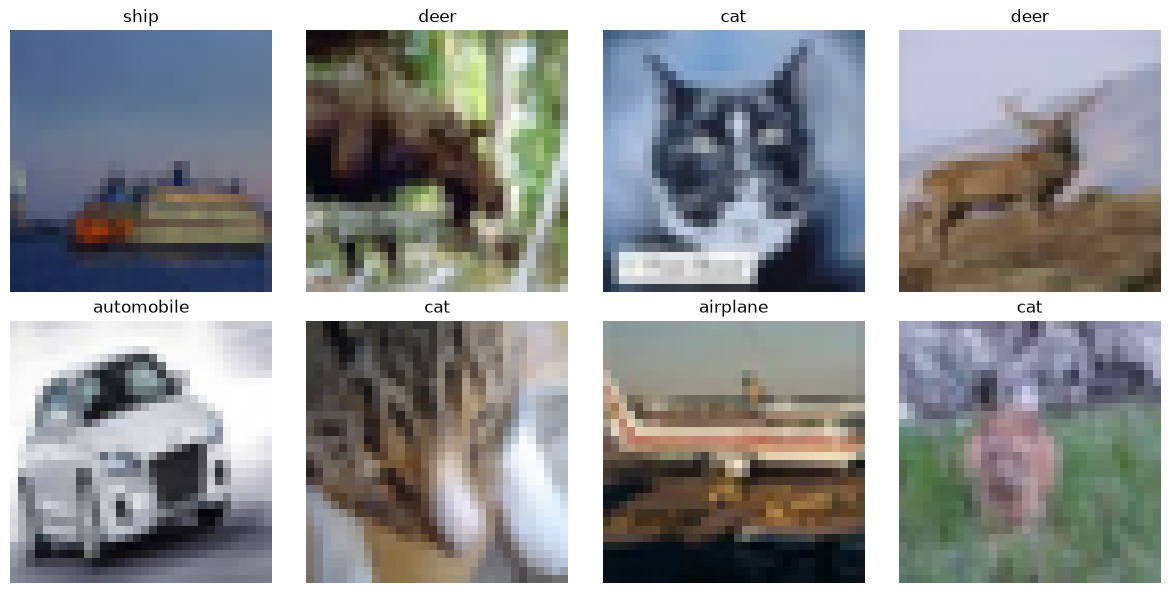

Saved to: /Users/yokou/Projects/cifar10-image-classifier/outputs/figures/sample_images.png


In [12]:
num_images = 8

indices = random.sample(
    range(len(train_dataset)),
    num_images
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, index in zip(axes.flatten(), indices):

    image, label = train_dataset[index]

    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()

save_path = FIGURE_DIR / "sample_images.png"

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", save_path)